### Imports and Setup

In [1]:
import itertools

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from tqdm.notebook import tqdm

from hnxwidget import HypernetxWidget
import hypernetx as hnx
import hypernetx.algorithms.hypergraph_modularity as hmod
import networkx as nx

from whale_gunshot_localization import config
import whale_gunshot_localization.utils.graph_tools as graph_tools
import whale_gunshot_localization.utils.math_tools as math_tools

### Generate Synthetic Measurements

Functions to randomly generate the measurements/sources/associations and visualize the results

In [2]:
def generate_measurements(num_sources, var=10, num_delete=0, seed=1111):
    """
    Generate some synthetic measurements to test with data association/localization algoritms.
    
    Parameters
    ----------
    num_sources : int
        maximum number of sources
    var : float
        variance of Gaussian noise added to range measurements
    num_delete : int
        maximum number of measurements to hide/delete at each TOSSIT
    seed : int
        seed for RNG
        
    Returns
    -------
    range_measurements : List[array-like]
        each sublist contains range measurements and is associated with a particular TOSSIT
    source_associations : List[array-like]
        same shape as range_measurements. each sublist contains numbers which associate the
        range_measurement in the corresponding spot in the data structure with a source.
    TOSSIT_association : List[array-like]
        same shape as range_measurements. each sublist contains numbers which associate the
        range_measurement in the corresponding spot in the data structure with a TOSSIT.    
    source_locs : array-like[array-like]
        matrix of generated source locations
    """ 
    
    # check inputs
    assert num_sources > 0, "number of sources must be non-negative"
    assert num_delete >= 0, "max signals to delete at each sensor must be non-negative"
    
    # get TOSSIT locations and extreme coordinate values
    TOSSIT_locations = np.asarray([config['TOSSIT']['TOSSIT_y'], config['TOSSIT']['TOSSIT_x']]).T
    min_x = config['scaling']['min_x']
    max_x = config['scaling']['max_x']
    min_y = config['scaling']['min_y']
    max_y = config['scaling']['max_y']

    # instantiate random number generator
    rng = np.random.default_rng(seed)
    
    # choose number of sources and generate source locations
    n = rng.choice(np.arange(1,num_sources+1))
    source_locs = np.concatenate((rng.uniform(min_y, max_y, size=(n,1)), rng.uniform(min_x, max_x, size=(n,1))), axis=1)
    
    # generate range measurements and log associations
    range_measurements, TOSSIT_associations, del_list, source_associations = [], [], [], []
    for t in range(TOSSIT_locations.shape[0]):
        
        # calculate range measurements from all sources to TOSSIT t, adding Gaussian noise
        r = np.linalg.norm(source_locs - TOSSIT_locations[t,:], axis=1) + \
            rng.normal(loc=0, scale=np.sqrt(var), size=n)
        range_measurements.append(r)
        
        # generate arrays for the TOSSIT associations of the measuremnts.
        TOSSIT_associations.append(np.ones((n,), dtype=int) * t)
        
        # randomly generate number of signals to delete at each TOSSIT. 
        # ensure that we have at least one signal per TOSSIT for simplicity.
        to_delete = rng.choice(np.arange(min(num_delete+1, len(range_measurements[t]))))
        del_list.append(to_delete)
        
        # generate arrays of source associations for the measurements
        source_associations.append(np.arange(n))        
    
    # perform deletions
    for i, (m, a, t, d) in enumerate(zip(range_measurements, source_associations, TOSSIT_associations, del_list)):
        if d:
            del_idx = rng.choice(np.arange(len(m)), replace=False, size=d)
            range_measurements[i] = np.delete(m, del_idx)
            source_associations[i] = np.delete(a, del_idx)
            TOSSIT_associations[i] = np.delete(t, del_idx)
                
    # make sure smallest association value is 0
    bias = min([a[0] for a in source_associations if len(a)])
    if bias > 0:
        for i, a in enumerate(source_associations):
            source_associations[i] = a - bias
    
    return range_measurements, source_associations, TOSSIT_associations, source_locs

def visualize_collection(measurements, TOSSIT_associations, source_associations, source_locs):
    """
    Display the ground truth range measurements as lines connecting sources and sensors as well as
    the ground truth data associations which are denoted by color.
    
    Parameters
    ----------
    measurements : List[array-like]
        each sublist contains range measurements and is associated with a particular TOSSIT
    source_associations : List[array-like]
        same shape as range_measurements. each sublist contains numbers which associate the
        range_measurement in the corresponding spot in the data structure with a source.
    TOSSIT_association : List[array-like]
        same shape as range_measurements. each sublist contains numbers which associate the
        range_measurement in the corresponding spot in the data structure with a TOSSIT.    
    source_locs : array-like[array-like]
        matrix of generated source locations
    """
    
    # instantiate random number generator (used for color generation
    # only, so no need for custom seed)
    rng = np.random.default_rng(1111)
    
    # load TOSSIT locations
    TOSSIT_locations = np.asarray([config['TOSSIT']['TOSSIT_y'], config['TOSSIT']['TOSSIT_x']]).T

    # plot sources and sensor locations
    plt.figure()
    plt.plot(TOSSIT_locations[:,1], TOSSIT_locations[:,0], '^', label='sensor', markersize=12, markeredgewidth=2)
    plt.plot(source_locs[:,1], source_locs[:,0], 'o', label='source')
    
    # get unique colors for each source
    color_list = [rng.uniform(0, 1, size=3) for _ in range(source_locs.shape[0])]
    
    # get group of measurements, associated TOSSITs, and associated sources
    for i, (m, t, a) in enumerate(zip(measurements, TOSSIT_associations, source_associations)):
        # for each measurement, draw line between associated TOSSIT and source
        for j, (mm, tt, aa) in enumerate(zip(m, t, a)):
            plt.plot([TOSSIT_locations[tt,1], source_locs[aa,1]], [TOSSIT_locations[tt,0], source_locs[aa,0]], '--', color=color_list[aa])
    
    # final touches on plot
    plt.gca().invert_yaxis()
    plt.xlabel("X [m]")
    plt.ylabel("Y [m]")
    plt.title("Ideal Measurements/Associations")
    plt.legend(["sensor", "source", "source range measurement"],bbox_to_anchor=(1.05, 1.0), loc='upper left')
    plt.show()

def visualize_measurements(measurements, TOSSIT_associations, source_associations, source_locs, buffer=10000, figsize=(5,20)):
    """
    Visualize actual noisey measurements using circles centered about the TOSSIT used to make the measurement as
    well as the ground truth data associations which are donoted by colors. Plots show each source individually
    as well as all of them aggregated together.
    
    Parameters
    ----------
    measurements : List[array-like]
        each sublist contains range measurements and is associated with a particular TOSSIT
    source_associations : List[array-like]
        same shape as range_measurements. each sublist contains numbers which associate the
        range_measurement in the corresponding spot in the data structure with a source.
    TOSSIT_association : List[array-like]
        same shape as range_measurements. each sublist contains numbers which associate the
        range_measurement in the corresponding spot in the data structure with a TOSSIT.    
    source_locs : array-like[array-like]
        matrix of generated source locations
    buffer : float
        how much beyond the simulated bounds to display in the visualizations
    figsize : Tuple[int, int]
        figsize for each of the isolated source subplots
    """
    
    # instantiate random number generator (used for color generation
    # only, so no need for custom seed)
    rng = np.random.default_rng(1111)
    
    # load TOSSIT locations
    TOSSIT_locations = np.asarray([config['TOSSIT']['TOSSIT_y'], config['TOSSIT']['TOSSIT_x']]).T
    min_x = config['scaling']['min_x']
    max_x = config['scaling']['max_x']
    min_y = config['scaling']['min_y']
    max_y = config['scaling']['max_y']
    max_r = config['scaling']['max_r']
    
    # figures for each source
    fig, axs = plt.subplots(source_locs.shape[0],1, figsize=figsize)
    
    # figure for all sources
    ag_fig = plt.figure()
    ag_fig.add_subplot(111)
    ag_ax = ag_fig.axes[0]
    if not isinstance(axs, np.ndarray):
        axs = np.asarray([axs])
        
    # plot associated measurements
    color_list = [rng.uniform(0, 1, size=3) for _ in range(source_locs.shape[0])]
    a_is_labeled = np.zeros((source_locs.shape[0],))
    a_ag_labeled = False
    for i, (m, t, a) in enumerate(zip(measurements, TOSSIT_associations, source_associations)):
        # plot sources and sensor locations
        for j, (mm, tt, aa) in enumerate(zip(m, t, a)):
            
            # plot range measurement
            circle1 = plt.Circle((TOSSIT_locations[tt,1], TOSSIT_locations[tt,0]), mm, color=color_list[aa], fill=False, label='range measurement' if not a_is_labeled[aa] else None)
            circle2 = plt.Circle((TOSSIT_locations[tt,1], TOSSIT_locations[tt,0]), mm, color=color_list[aa], fill=False, label='range measurement' if not a_ag_labeled else None)
            axs[aa].add_artist(circle1)
            ag_ax.add_artist(circle2)
            
            # keep track of if we have a labeled measurement
            # for each assocaition.
            if not a_is_labeled[aa]:
                a_is_labeled[aa] = 1
                a_ag_labeled = True
    
    # plot common elements among subplots
    for i, ax in enumerate(list(axs) + [ag_ax]):
        ax.plot(TOSSIT_locations[:,1], TOSSIT_locations[:,0], '^', markersize=12, label='sensor', markeredgewidth=2)
        ax.set_xlabel("X [m]")
        ax.set_ylabel("Y [m]")
        ax.set_xlim([min_x-buffer, max_x+buffer])
        ax.set_ylim([min_y-buffer, max_y+buffer])
        for a in range(source_locs.shape[0]):
            ax.plot(source_locs[a,1], source_locs[a,0], 'o', color=color_list[a], label='source' if a == 0 else None)
        ax.invert_yaxis()
        if i == source_locs.shape[0]:
            ag_ax.set_title("Aggregate Measurement/Association Visualization")
        else:
            ax.set_title("Measurement/Association Visualization")
        
        # set up legend accounting for if a source has no recieved measurements
        try:
            handles, labels = ax.get_legend_handles_labels()
            order = [1,2,0]
            ax.legend([handles[idx] for idx in order],[labels[idx] for idx in order], bbox_to_anchor=(1.05, 1.0), loc='upper left')
            leg = ax.get_legend()
            leg.legendHandles[1].set_color('black')
            leg.legendHandles[2].set_color('black')
        except:
            ax.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
            leg = ax.get_legend()
            leg.legendHandles[1].set_color('black')
    plt.show()

Generate the measurements

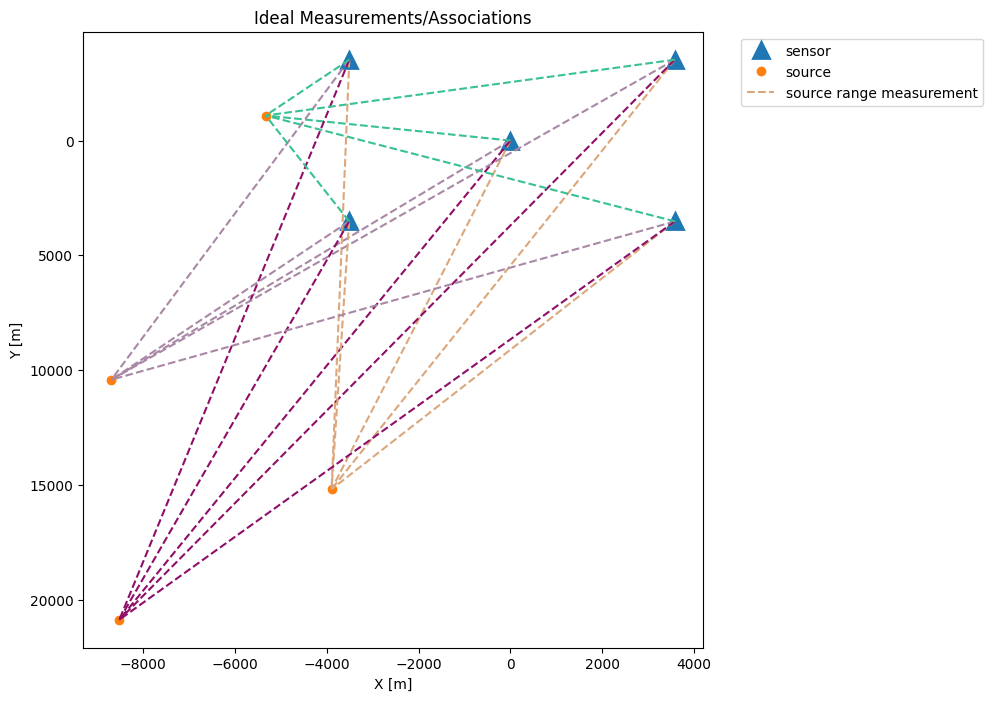

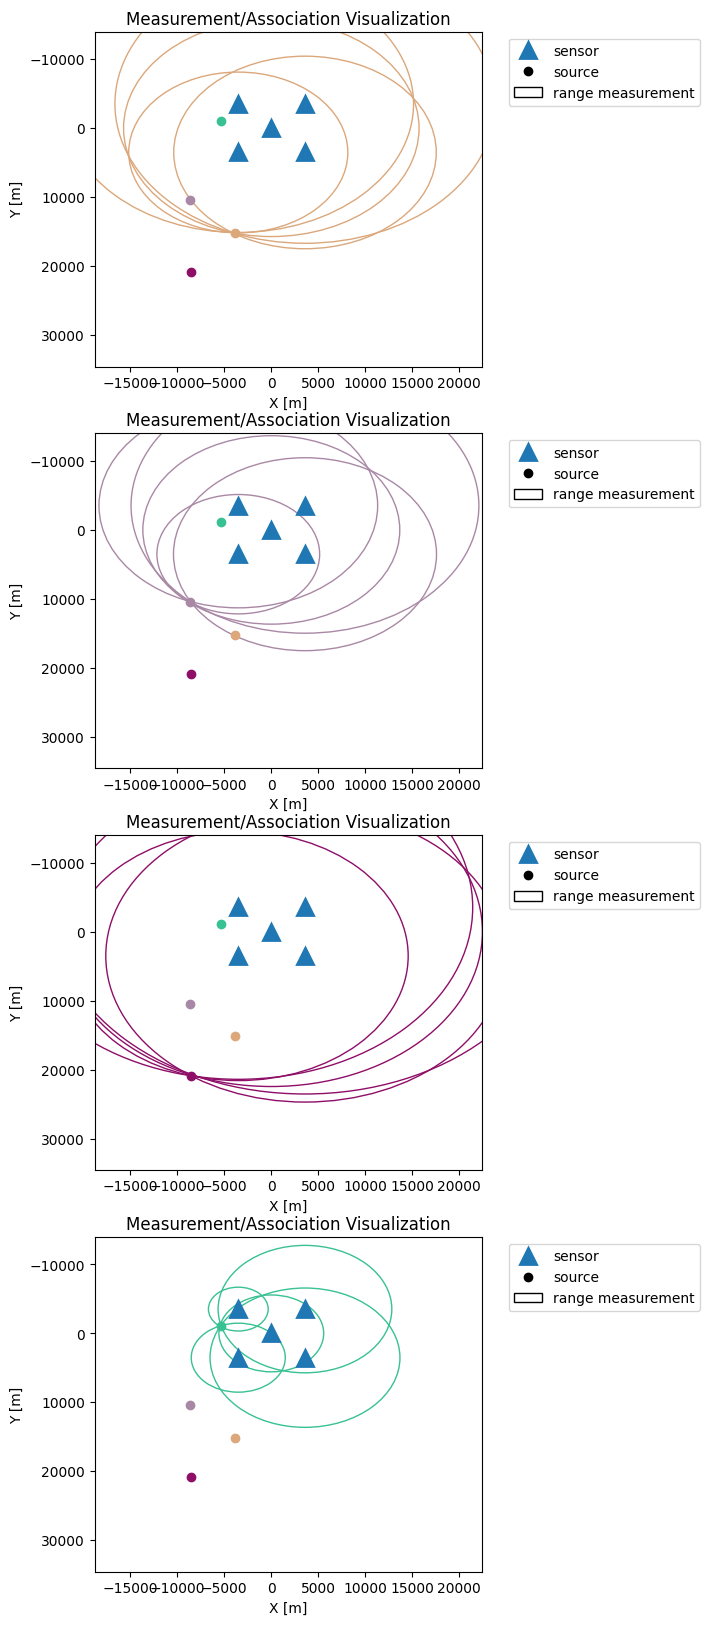

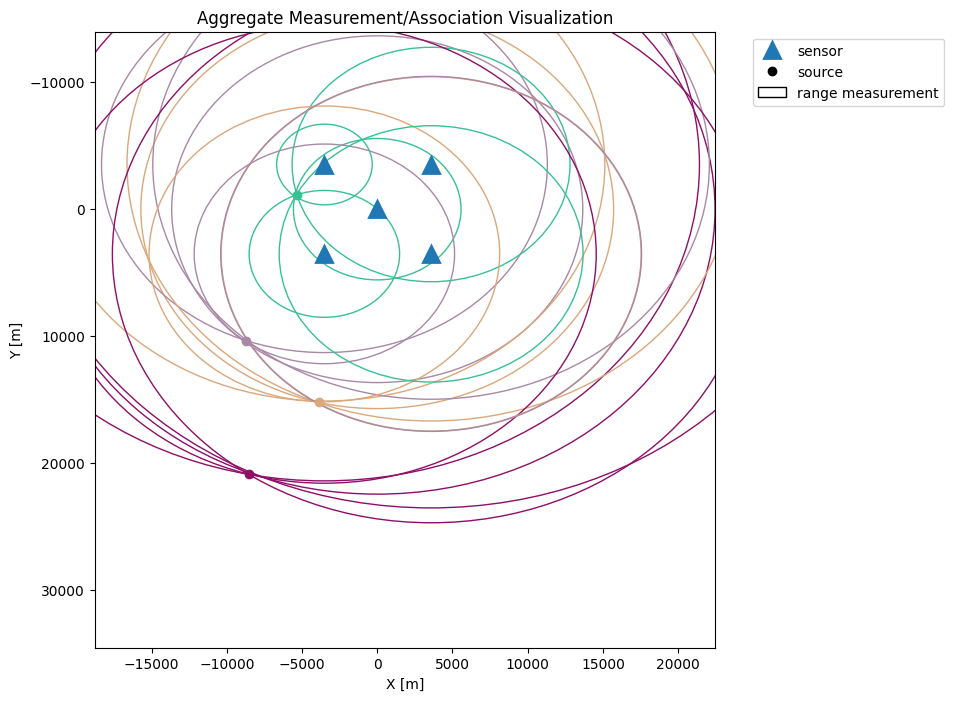

In [4]:
# generate measurements and associations
measurements, source_associations, TOSSIT_associations, source_locs = generate_measurements(num_sources=5, var=10000, num_delete=0, seed=1524)

# visualize results
visualize_collection(measurements, TOSSIT_associations, source_associations, source_locs)
print(100*"=")
visualize_measurements(measurements, TOSSIT_associations, source_associations, source_locs)

### Graph-Based Approach

In [54]:
class Localizer:
    """
    Class to perform data association and range-based localization using 
    multiple range measurements from multiple sensors.
    
    ...
    
    Attributes
    ----------
    TOSSIT_locations : array-like of shape N X 2
        locations of the acoustic sensors or the form [y, x]
    measurements : List[array-like]
        each sublist contains range measurements associated with a particular sensor
    H : hypernetx.classes.hypergraph.Hypergraph
        hypergraph object
    k : int
        number of measurements to group when checking for measurement group consistency
    consistency_thresh : float
        threshold for distance from range to location to determine which measurements groups
        are self-consistent
    method_thresh : float in [0, 1]
        threshold to determine if approximation of H matrix from doi:10.1017/S0263574710000196
        is sufficient and determines whether to use closed-form or gradient-based localization approch
    prune : bool
        whether to prune measurement groups based on lack of range measurement intersection
    min_x : float
        minimum x coordinate used to generate simulated data for detection/range estimation network training.
        used to generate an initial guess for iterative optimization method.
    max_x : float
        maximum x coordinate used to generate simulated data for detection/range estimation network training.
        used to generate an initial guess for iterative optimization method.
    min_y : float
        minimum y coordinate used to generate simulated data for detection/range estimation network training.
        used to generate an initial guess for iterative optimization method.
    max_y : float
        maximum y coordinate used to generate simulated data for detection/range estimation network training.
        used to generate an initial guess for iterative optimization method.
    """
    
    def __init__(self, k, consistency_thresh=1000, method_thresh=0.95, prune=False):
        """
        Construct attributes
        
        Parameters
        ----------
        k : int
            number of measurements to group when checking for measurement group consistency
        consistency_thresh : float
            threshold for distance from range to location to determine which measurements groups
            are self-consistent
        method_thresh : float in [0, 1]
            threshold to determine if approximation of H matrix from doi:10.1017/S0263574710000196
            is sufficient and determines whether to use closed-form or gradient-based localization approch
        prune : bool
            whether to prune measurement groups based on lack of range measurement intersection
        """
        
        # load TOSSIT locations
        self.TOSSIT_locations = np.asarray([config['TOSSIT']['TOSSIT_y'], config['TOSSIT']['TOSSIT_x']]).T
        
        # initialize empty measurements and hypergraph
        self.measurements = None
        self.H = None
        self._linear_measurements = None
        
        # uniformity constant for hypergraph
        if k > 3:
            self.k = k
        else:
            raise ValueError("k must be > 3.")
        
        # thresholds
        self.consistency_thresh = consistency_thresh
        self.method_thresh = method_thresh
        
        # prune sets of k measurements based on pairwise intersection check
        self.prune = prune
        
        # get bounds of considered grid
        self.min_x = config['scaling']['min_x']
        self.max_x = config['scaling']['max_x']
        self.min_y = config['scaling']['min_y']
        self.max_y = config['scaling']['max_y'] 
    
    def _localize(self, ranges, sensors_idx):
        """
        An iterative localization method based on minimizing the following cost function:
        
        (1 / N) * \sum_{i=1}^{N} (||p_{i} - p_{0}||_{2} - r_{i})^{2}.
        
        Parameters
        ----------
        ranges : array-like of shape M,
            list of range measurements from source to sensor
        sensors_idx : array-like of shape M,
            list of sensor indices associated with the provided range measurements
            
        Returns
        -------
        res.fun : float
            cost function value
        res.x : array-like
            optimized location
        """
        
        # define objective function
        def obj(x):
            # calculate l2s between TOSSIT positions and predicted location
            l2 = np.sqrt((self.TOSSIT_locations[sensors_idx,0] - x[0]) ** 2 + (self.TOSSIT_locations[sensors_idx,1] - x[1]) ** 2)

            # return sum squared error between l2s and predicted ranges
            return (1/len(ranges))*np.sum((l2.squeeze() - ranges) ** 2)
        
        # random initial guess
        x0 = [np.random.uniform(self.min_y, self.max_y), np.random.uniform(self.min_x, self.max_x)]
        
        # optimize!
        res = minimize(obj, x0, method='Nelder-Mead', options={'disp': False})
        
        return res.fun, res.x
    
    def _hybrid_localize(self, ranges, sensors_idx):
        """
        Hybrid localization method which choses between slower iterative method
        and the closed form method presented in doi:10.1017/S0263574710000196.
        
        Parameters
        ----------
        ranges : array-like of shape M,
            list of range measurements from source to sensor
        sensors_idx : array-like of shape M,
            list of sensor indices associated with the provided range measurements
            
        Returns
        -------
        array-like
            optimized location
        """
        
        # get sensors and save how many
        p_i = self.TOSSIT_locations.T[:,sensors_idx]
        N = p_i.shape[1]

        # calculate a, B, c, H
        a = (p_i * (p_i * p_i).sum(axis=0, keepdims=True) \
             - (ranges**2 * p_i)).sum(axis=1, keepdims=True) / N

        eye = np.dstack(N*[np.eye(2)])
        B = ((-2*np.einsum('ij,kj->jik', p_i, p_i)).sum(axis=0) \
             + (-(np.expand_dims((p_i * p_i).sum(axis=0, keepdims=True), axis=0) * eye) \
             + np.expand_dims(ranges**2, axis=0) * eye).sum(axis=2)) / N

        c = p_i.sum(axis=1, keepdims=True) / N

        H = (-2 / N)*(np.einsum('ij,kj->jik', p_i, p_i).sum(axis=0)) + (2*c @ c.T)
        
        if np.linalg.matrix_rank(H) < 2:
            raise RuntimeError('H matrix not full rank.')
        else:
            # check if approximation holds to make H matrix.
            # if not, use gradient-based localization
            f = a + B @ c + 2*c @ c.T @ c
        
            q = -np.linalg.inv(H) @ f

            D = B + 2*c @ c.T + (c.T @ c) * np.eye(2)
            H_hat = D - (q.T @ q)*np.eye(2)
            
            dist = math_tools.matrix_similarity(H, H_hat)
            
            if dist < self.method_thresh:
                _, loc = self._localize(ranges, sensors_idx)
                return loc
            return (q + c).squeeze() 
        
    def set_measurements(self, measurements):
        """
        Create a hypergraph which represents groups of k-consistent measurements.
        
        Parameters
        ----------
        measurements : List[array-like]
            each sublist contains range measurements associated with a particular sensor
        """
        
        # update measurements
        self.measurements = measurements

        ######################################################
        #               create formatted lists               #
        ######################################################

        # set of sensor indices with measurements
        non_empty_sensors = set()
        # list of all measurements traversed sensor-major
        self._linear_measurements = []
        # same shape as measurements but with linear indices
        formatted_linear_idx = [[] for _ in range(self.TOSSIT_locations.shape[0])]
        # measurement to linear index dict
        measurement_to_linear_idx = {}
        # (mesaurement, sensor_id) elements
        self._tuple_idx = []
        for i, m_list in enumerate(self.measurements):
            for j, m in enumerate(m_list):

                # keep track of sensors with measurements
                non_empty_sensors.add(i)

                # keep track of linear index
                linear_idx = len(self._linear_measurements)
                formatted_linear_idx[i].append(linear_idx)
                measurement_to_linear_idx[m] = linear_idx

                # keep linear list of measurements
                self._linear_measurements.append(m)

                self._tuple_idx.append((i, j))

        # convert linear_measurements to numpy array
        self._linear_measurements = np.asarray(self._linear_measurements)
        self._tuple_idx = np.asarray(self._tuple_idx)

        ######################################################
        #                  build hypergraph                  #
        ######################################################

        # get all combinations of sensor indices
        sensor_combs = itertools.combinations(non_empty_sensors, self.k)

        # for each group of k sensors, get valid measurement combination
        # candidates based on trilateration errors
        scenes = {}
        edge_set_counter = 0
        for s_comb in sensor_combs:

            # get range measurment indices associated with specified sensors in s_comb
            ranges = [formatted_linear_idx[sensor_idx] for sensor_idx in s_comb]

            # get all combinations of measurement indices across the sensors as List[List]
            range_combos = map(list, itertools.product(*ranges))

            # determine which candidates are consistent
            for range_combo in range_combos:

                range_subcombos = list(map(list,itertools.combinations(range_combo, self.k-1)))
                s_subcombos = list(map(list, itertools.combinations(s_comb, self.k-1)))

                append = True
                for range_subcombo, s_subcombo in zip(range_subcombos, s_subcombos):

                    # prune groups of k measurements based if any of the pairs don't intersect
                    if self.prune and not math_tools.check_intersection(self.TOSSIT_locations[s_subcombo,:], self._linear_measurements[range_subcombo]):
                        append = False
                        break

                    # get trilateration cost for candidate
                    loc = self._hybrid_localize(self._linear_measurements[range_subcombo], s_subcombo)

                    r = (set(range_combo) - set(range_subcombo)).pop()
                    s = (set(s_comb) - set(s_subcombo)).pop()
                    if math_tools.point_circle_shortest_distance(self.TOSSIT_locations[s,:], self._linear_measurements[r], loc) > self.consistency_thresh:
                        append = False
                        break

                if not append:
                    continue
                else:
                    scenes[edge_set_counter] = range_combo
                    edge_set_counter += 1

        # save hypergraph
        if len(scenes):
            self.H = hnx.Hypergraph(scenes)
            return True
        return False
        
    def associate_and_localize(self, method='clique'):
        """
        Using the hypergraph constructed in self.set_measurements, perform data association
        and localization.
        
        Parameters
        ----------
        method : string
            can be either 'clique' or 'partition'
        """
        
        # make sure we've set measurements
        assert self.measurements, "measurements have not been set"
        
        associations = []
        
        if method == 'clique':
            for h in self.H.connected_component_subgraphs():
                for clique in nx.find_cliques_recursive(h):
                    if len(clique) >= 3:
                        associations.append(clique)
        elif method == 'partition':
            HG = hmod.precompute_attributes(l.H)
            associations = hmod.kumar(HG)
            # associations = graph_tools.last_step(HG, A, wdc=hmod.linear)
        else:
            raise ValueError("Method must be either 'clique' or 'partition'")
        
        locs = []
        for a in associations:
            a = list(a)
            sensors = [self._tuple_idx[idx][0] for idx in a]
            ranges = self._linear_measurements[a]
            _, loc = self._localize(ranges, sensors)
            locs.append(loc)
        
        locs = np.asarray(locs)
        
        return associations, locs

In [55]:
l = Localizer(k=4, consistency_thresh=1500, method_thresh=0.95, prune=True)

In [56]:
%%time
l.set_measurements(measurements)

CPU times: user 863 ms, sys: 629 ms, total: 1.49 s
Wall time: 745 ms


In [46]:
assoc, locs_est = l.associate_and_localize(method='partition')
print(assoc)

In [48]:
HypernetxWidget(l.H)

HypernetxWidget(component='HypernetxWidget', props={'nodes': [{'uid': '12'}, {'uid': '8'}, {'uid': '17'}, {'ui…

In [49]:
def plot_localization(locs_est, source_locs, buffer=6000): 
    
    # load constants
    TOSSIT_locations = np.asarray([config['TOSSIT']['TOSSIT_y'], config['TOSSIT']['TOSSIT_x']]).T
    min_x = config['scaling']['min_x']
    max_x = config['scaling']['max_x']
    min_y = config['scaling']['min_y']
    max_y = config['scaling']['max_y']

    plt.plot(TOSSIT_locations[:,1], TOSSIT_locations[:,0], '^', markersize=12, label='sensor', markeredgewidth=2)
    plt.plot(source_locs[:,1], source_locs[:,0], 'o', label='ground truth')
    plt.plot(locs_est[:,1], locs_est[:,0], 'x', label='estimate', markeredgewidth=2)
    plt.xlabel("X [m]")
    plt.ylabel("Y [m]")
    plt.xlim([min_x-buffer, max_x+buffer])
    plt.ylim([min_y-buffer, max_y+buffer])
    plt.gca().invert_yaxis()
    plt.legend()
    plt.show()

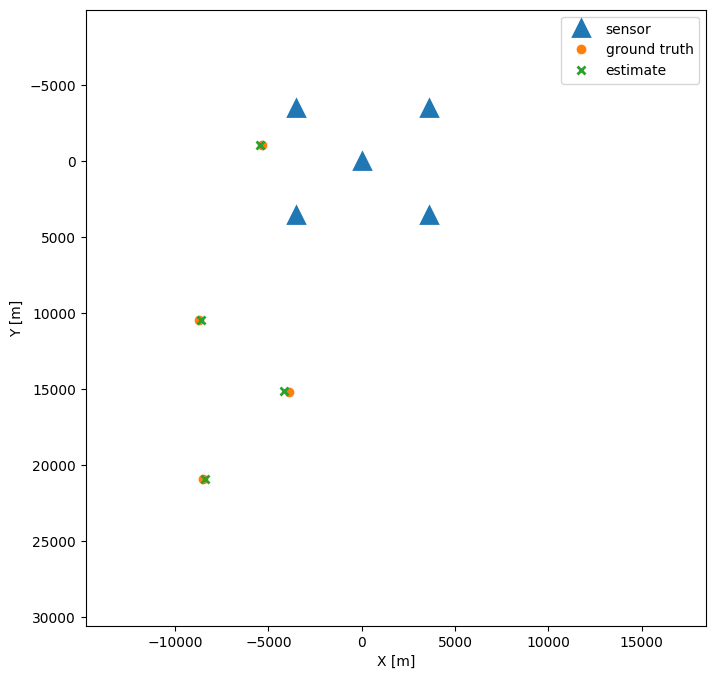

In [50]:
plot_localization(locs_est, source_locs)

In [12]:
def localize(ranges, sensors_idx):
    
    TOSSIT_locations = np.asarray([config['TOSSIT']['TOSSIT_y'], config['TOSSIT']['TOSSIT_x']]).T
    min_x = config['scaling']['min_x']
    max_x = config['scaling']['max_x']
    min_y = config['scaling']['min_y']
    max_y = config['scaling']['max_y']
    
    # define objective function
    def obj(x):
        # calculate l2s between TOSSIT positions and predicted location
        l2 = np.sqrt((TOSSIT_locations[sensors_idx,0] - x[0]) ** 2 + (TOSSIT_locations[sensors_idx,1] - x[1]) ** 2)

        # return sum squared error between l2s and predicted ranges
        return (1/len(ranges))*np.sum((l2.squeeze() - ranges) ** 2)

    # random initial guess
    x0 = [np.random.uniform(min_y, max_y), np.random.uniform(min_x, max_x)]

    # optimize!
    res = minimize(obj, x0, method='Nelder-Mead', options={'disp': False})

    return res.fun, res.x

In [13]:
measurements = np.asarray(measurements)

In [14]:
measurements.shape

(5, 1)

In [15]:
%%time
localize(measurements.squeeze(), np.asarray([0, 1, 2, 3, 4]))

CPU times: user 12 ms, sys: 3.93 ms, total: 15.9 ms
Wall time: 11.5 ms


(9537693.913728353, array([10688.58166575,  6847.37367773]))

In [17]:
m2 = measurements.T

In [55]:
def fast_localize(ranges, sensors_idx):
    
    # get sensors and save how many
    p_i = np.asarray([config['TOSSIT']['TOSSIT_y'], config['TOSSIT']['TOSSIT_x']])[:,sensors_idx]
    N = p_i.shape[1]
    
    # calculate a, B, c, H, f from doi:10.1017/S0263574710000196
    a = (p_i * (p_i * p_i).sum(axis=0, keepdims=True) \
         - (ranges**2 * p_i)).sum(axis=1, keepdims=True) / N
    
    eye = np.dstack(N*[np.eye(2)])
    B = (-2*np.einsum('ij,kj->jik', p_i, p_i)).sum(axis=0) \
         - ((np.expand_dims((p_i * p_i).sum(axis=0, keepdims=True), axis=0) * eye \
         + np.expand_dims(ranges**2, axis=0) * eye)).sum(axis=2) / N
    
    c = p_i.sum(axis=1, keepdims=True) / N
    
    H = (-2 / N)*(np.einsum('ij,kj->jik', p_i, p_i).sum(axis=0)) + (2*c @ c.T)
    
    f = a + B @ c + 2*c @ c.T @ c
    
    q = -np.linalg.inv(H) @ f
    
    D = B + 2*c @ c.T + (c.T @ c) * np.eye(2)
    H_hat = D - (q.T @ q)*np.eye(2)
    print(np.linalg.matrix_rank(H))
    
    if np.linalg.matrix_rank(H) < 2:
        pass
    else:
        return (-np.linalg.inv(H) @ f + c).squeeze()

In [56]:
%%time
fast_localize(m2, np.asarray([0, 1, 2, 3, 4]))

2
CPU times: user 648 µs, sys: 439 µs, total: 1.09 ms
Wall time: 582 µs


array([18257.22802952, 13955.56215257])